<a href="https://colab.research.google.com/github/sona0024/COVID-19-Clinical-Trials-/blob/main/COVID_19_EDA_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")


In [ ]:
# Load the dataset
file_path = 'COVID clinical trials.csv'
df = pd.read_csv(file_path)

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())


First 5 rows of the dataset:
   Rank   NCT Number                                              Title  \
0     1  NCT04785898  Diagnostic Performance of the ID Now™ COVID-19...   
1     2  NCT04595136  Study to Evaluate the Efficacy of COVID19-0001...   
2     3  NCT04395482  Lung CT Scan Analysis of SARS-CoV2 Induced Lun...   
3     4  NCT04416061  The Role of a Private Hospital in Hong Kong Am...   
4     5  NCT04395924         Maternal-foetal Transmission of SARS-Cov-2   

        Acronym                  Status         Study Results  \
0   COVID-IDNow  Active, not recruiting  No Results Available   
1      COVID-19      Not yet recruiting  No Results Available   
2   TAC-COVID19              Recruiting  No Results Available   
3      COVID-19  Active, not recruiting  No Results Available   
4  TMF-COVID-19              Recruiting  No Results Available   

                                          Conditions  \
0                                            Covid19   
1                

In [ ]:
# Shape of the dataset
print("Dataset Shape (rows, columns):", df.shape)

# Column names and data types
print("\nColumn Info:")
print(df.dtypes)

# Summary statistics for numeric columns
print("\nSummary Statistics:")
print(df.describe(include='all'))


Dataset Shape (rows, columns): (5783, 27)

Column Info:
Rank                         int64
NCT Number                  object
Title                       object
Acronym                     object
Status                      object
Study Results               object
Conditions                  object
Interventions               object
Outcome Measures            object
Sponsor/Collaborators       object
Gender                      object
Age                         object
Phases                      object
Enrollment                 float64
Funded Bys                  object
Study Type                  object
Study Designs               object
Other IDs                   object
Start Date                  object
Primary Completion Date     object
Completion Date             object
First Posted                object
Results First Posted        object
Last Update Posted          object
Locations                   object
Study Documents             object
URL                         object

In [ ]:
# Check for missing values in each column
print("\nMissing Values in Each Column:")
print(df.isnull().sum())



Missing Values in Each Column:
Rank                          0
NCT Number                    0
Title                         0
Acronym                    3303
Status                        0
Study Results                 0
Conditions                    0
Interventions               886
Outcome Measures             35
Sponsor/Collaborators         0
Gender                       10
Age                           0
Phases                     2461
Enrollment                   34
Funded Bys                    0
Study Type                    0
Study Designs                35
Other IDs                     1
Start Date                   34
Primary Completion Date      36
Completion Date              36
First Posted                  0
Results First Posted       5747
Last Update Posted            0
Locations                   585
Study Documents            5601
URL                           0
dtype: int64


In [ ]:
# Drop rows where essential columns are missing
df.dropna(subset=['Phases', 'Study Type', 'Start Date'], inplace=True)


In [ ]:
# Drop duplicate rows
df.drop_duplicates(inplace=True)


In [ ]:
# Standardize 'Phases' and 'Study Type'
df['Phases'] = df['Phases'].str.strip().str.title()
df['Study Type'] = df['Study Type'].str.strip().str.title()
df['Status'] = df['Status'].str.strip().str.title()


In [ ]:
# Convert date columns to datetime
date_cols = ['Start Date', 'Primary Completion Date', 'Completion Date']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [ ]:
# Encode 'Study Type' into numeric codes
df['Study Type Code'] = df['Study Type'].astype('category').cat.codes


In [ ]:
# Create a new column for study duration in days
df['Study Duration (days)'] = (df['Completion Date'] - df['Start Date']).dt.days


In [ ]:
# Display first few rows of the cleaned dataset
print("\nCleaned Data Preview:")
print(df.head())



Cleaned Data Preview:
   Rank   NCT Number                                              Title  \
0     1  NCT04785898  Diagnostic Performance of the ID Now™ COVID-19...   
1     2  NCT04595136  Study to Evaluate the Efficacy of COVID19-0001...   
5     6  NCT04516954          Convalescent Plasma for COVID-19 Patients   
6     7  NCT04476940  COVID-19 Breastfeeding Guideline for African-A...   
8     9  NCT04602884  Early Detection of COVID-19 Using Breath Analysis   

       Acronym                   Status         Study Results  \
0  COVID-IDNow   Active, Not Recruiting  No Results Available   
1     COVID-19       Not Yet Recruiting  No Results Available   
5         CPCP  Enrolling By Invitation  No Results Available   
6     COVID-BF       Not Yet Recruiting  No Results Available   
8     COVID-19                Suspended  No Results Available   

                        Conditions  \
0                          Covid19   
1             SARS-CoV-2 Infection   
5                    

In [ ]:
# Value counts for trial status
if 'Status' in df.columns:
    print("\nTrial Status Counts:")
    print(df['Status'].value_counts())



Trial Status Counts:
Status
Recruiting                 1581
Not Yet Recruiting          654
Completed                   460
Active, Not Recruiting      351
Withdrawn                    96
Enrolling By Invitation      85
Terminated                   70
Suspended                    25
Name: count, dtype: int64


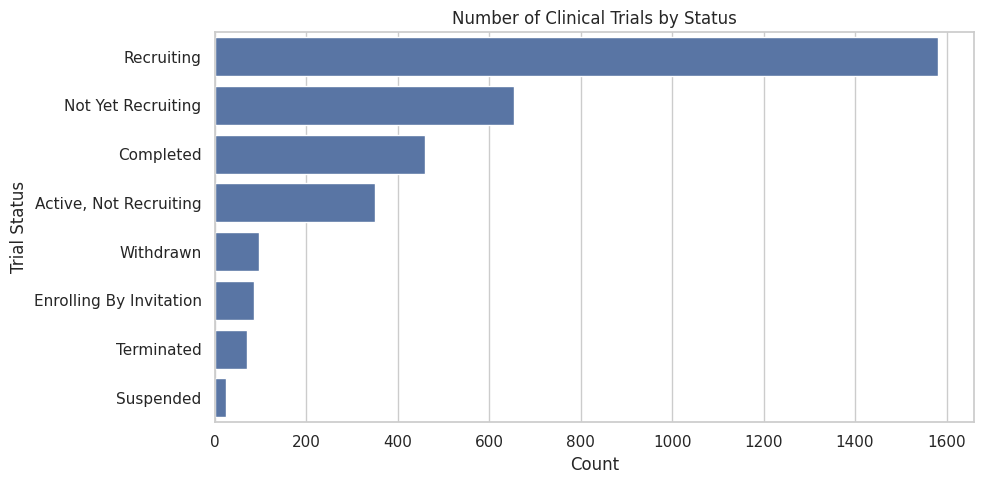

In [ ]:
if 'Status' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(y='Status', data=df, order=df['Status'].value_counts().index)
    plt.title('Number of Clinical Trials by Status')
    plt.xlabel('Count')
    plt.ylabel('Trial Status')
    plt.tight_layout()
    plt.show()


In [ ]:
if 'Intervention' in df.columns:
    top_interventions = df['Intervention'].value_counts().head(10)
    print("\nTop 10 Interventions:")
    print(top_interventions)

    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_interventions.values, y=top_interventions.index)
    plt.title('Top 10 Interventions in Trials')
    plt.xlabel('Count')
    plt.ylabel('Intervention')
    plt.tight_layout()
    plt.show()


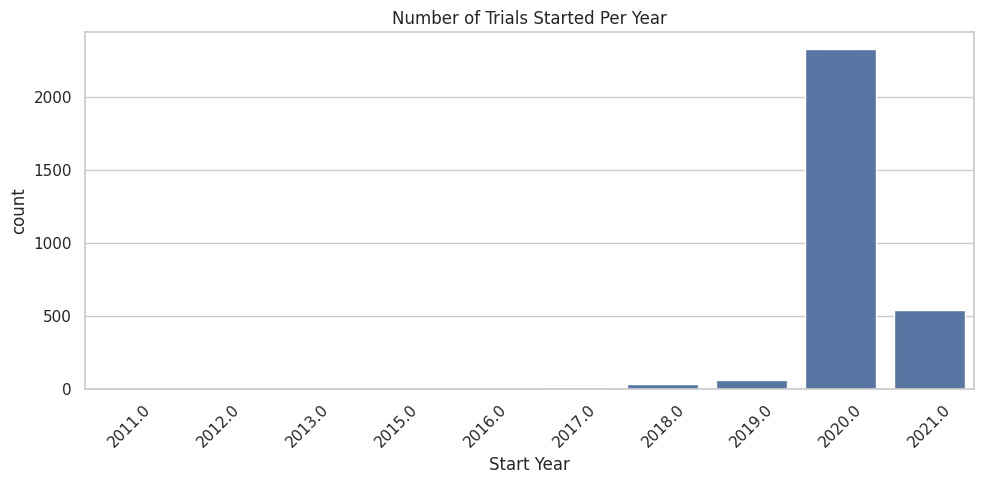

In [ ]:
if 'Start Date' in df.columns:
    df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
    df['Start Year'] = df['Start Date'].dt.year

    plt.figure(figsize=(10, 5))
    sns.countplot(x='Start Year', data=df, order=sorted(df['Start Year'].dropna().unique()))
    plt.title('Number of Trials Started Per Year')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [ ]:
import plotly.express as px

# Interactive bar chart for trial status
if 'Status' in df.columns:
    status_counts = df['Status'].value_counts().reset_index()
    status_counts.columns = ['Status', 'Count']

    fig = px.bar(status_counts, x='Count', y='Status', orientation='h',
                 title='Number of Clinical Trials by Status',
                 color='Status', text='Count')
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()


In [ ]:
if 'Start Date' in df.columns:
    df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
    df['Start Year'] = df['Start Date'].dt.year

    year_counts = df['Start Year'].value_counts().sort_index()
    fig = px.line(x=year_counts.index, y=year_counts.values, markers=True,
                  labels={'x': 'Start Year', 'y': 'Number of Trials'},
                  title='Clinical Trials Started Per Year')
    fig.show()


In [ ]:
if 'Intervention' in df.columns:
    top_interv = df['Intervention'].value_counts().head(10).reset_index()
    top_interv.columns = ['Intervention', 'Count']

    fig = px.bar(top_interv, x='Count', y='Intervention', orientation='h',
                 title='Top 10 Interventions in Clinical Trials',
                 text='Count', color='Intervention')
    fig.show()


In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Separate numeric and categorical columns
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns

# Impute numeric columns using mean
numeric_imputer = SimpleImputer(strategy='mean')
df[numeric_columns] = numeric_imputer.fit_transform(df[numeric_columns])

# Impute categorical columns using most frequent value (mode)
categorical_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_columns] = categorical_imputer.fit_transform(df[categorical_columns])

# Check the transformed data
print(df.isnull().sum())  # To check if any missing values remain


Rank                         0
NCT Number                   0
Title                        0
Acronym                      0
Status                       0
Study Results                0
Conditions                   0
Interventions                0
Outcome Measures             0
Sponsor/Collaborators        0
Gender                       0
Age                          0
Phases                       0
Enrollment                   0
Funded Bys                   0
Study Type                   0
Study Designs                0
Other IDs                    0
Start Date                 341
Primary Completion Date    954
Completion Date            990
First Posted                 0
Results First Posted         0
Last Update Posted           0
Locations                    0
Study Documents              0
URL                          0
Study Type Code              0
Study Duration (days)        0
Start Year                   0
dtype: int64


In [ ]:
# Encode categorical columns to numeric values using LabelEncoder
encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

# Check the encoded data
print(df.head())


   Rank  NCT Number  Title  Acronym  Status  Study Results  Conditions  \
0   1.0        3071   1001      331       0              1         691   
1   2.0        2289   2821      313       3              1        1442   
5   6.0        1873    887      430       2              1         167   
6   7.0        1661    550      326       3              1         765   
8   9.0        2318   1051      313       5              1         691   

   Interventions  Outcome Measures  Sponsor/Collaborators  Gender  Age  \
0           1128               977                    722       0   73   
1           1631               525                   1888       0   73   
5            536               993                   2312       0  104   
6             47               241                   1271       1   88   
8           1104               736                   1663       0   93   

   Phases  Enrollment  Funded Bys  Study Type  Study Designs  Other IDs  \
0       1      1000.0          14  

In [ ]:
# Assuming 'Status' is the target variable for classification
target_column = 'Status'

# Split the data into features (X) and target (y)
X = df.drop(columns=[target_column])
y = df[target_column]


In [ ]:
print(df.columns)


Index(['Rank', 'NCT Number', 'Title', 'Acronym', 'Status', 'Study Results',
       'Conditions', 'Interventions', 'Outcome Measures',
       'Sponsor/Collaborators', 'Gender', 'Age', 'Phases', 'Enrollment',
       'Funded Bys', 'Study Type', 'Study Designs', 'Other IDs', 'Start Date',
       'Primary Completion Date', 'Completion Date', 'First Posted',
       'Results First Posted', 'Last Update Posted', 'Locations',
       'Study Documents', 'URL', 'Study Type Code', 'Study Duration (days)',
       'Start Year'],
      dtype='object')


In [ ]:
# Select 'Enrollment' as the target variable
X = df.drop(columns=['Enrollment'])  # Features: All columns except 'Enrollment'
y = df['Enrollment']  # Target: 'Enrollment' column


In [ ]:
# Convert 'Start Date' to datetime and extract the year
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Start Year'] = df['Start Date'].dt.year

# Alternatively, you could also convert it to the number of days since a specific reference date
df['Start Date Numeric'] = (df['Start Date'] - pd.Timestamp('1970-01-01')).dt.total_seconds()  # Unix timestamp (seconds since 1970)


In [ ]:
# Perform One-Hot Encoding for categorical columns (e.g., 'Status', 'Conditions')
df = pd.get_dummies(df, columns=['Status', 'Conditions'], drop_first=True)


In [ ]:
# Select numeric columns only for features (X)
X = df.select_dtypes(include=['float64', 'int64'])  # Select only numeric columns

# Target variable (e.g., 'Enrollment')
y = df['Enrollment']

# Drop rows with missing values
X = X.dropna()
y = y[X.index]  # Align y with the dropped rows in X


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 2.8780352717014074e-21
R-squared: 1.0


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')


Mean Squared Error: 2.8780352717014074e-21
R-squared: 1.0
